### Taller 04: Descubriendo Patrones Musicales con Spotify ###

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. CARGA DIRECTA DESDE URL (Profe no pude cargar los datos desde mi pc, para que no de el error de FileNotFoundError lo cargue directo desde internet)
print("Cargando datos de Spotify directo desde internet...")
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

# 2. DEFINICIÓN DE CARACTERÍSTICAS
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo']

# Limpieza de nulos
df_clean = df.dropna(subset=features).copy()
X = df_clean[features]

# 3. ESCALADO OBLIGATORIO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA (3 Componentes)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]
df_clean['PC3'] = X_pca[:, 2]

# 5. CLUSTERING (K-Means con 4 grupos)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\n¡PROCESO COMPLETADO EXITOSAMENTE!")
print(f"Canciones procesadas: {df_clean.shape[0]}")
print(f"Varianza explicada por PCA: {np.sum(pca.explained_variance_ratio_):.2%}")

Cargando datos de Spotify directo desde internet...

¡PROCESO COMPLETADO EXITOSAMENTE!
Canciones procesadas: 32833
Varianza explicada por PCA: 44.10%


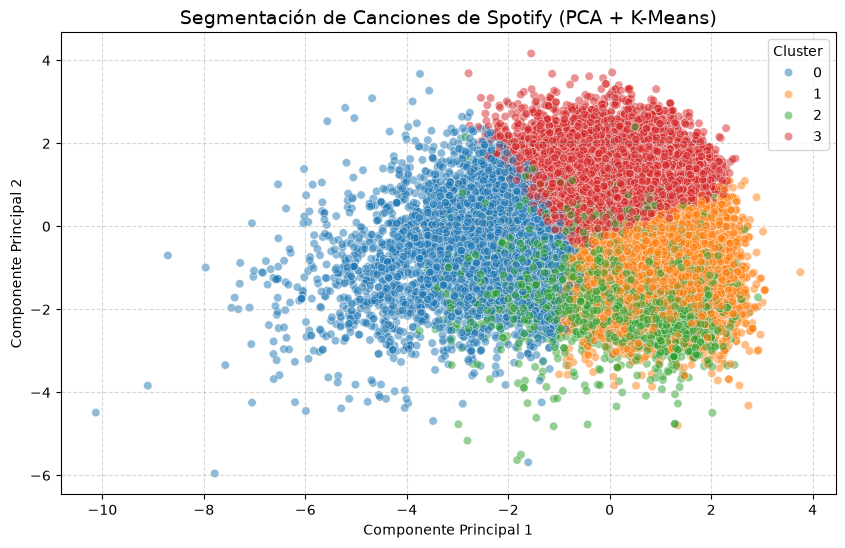

In [ ]:
#6. VISUALIZACIÓN

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster', 
    palette='tab10', 
    data=df_clean, 
    alpha=0.5
)
plt.title('Segmentación de Canciones de Spotify (PCA + K-Means)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#CONCLUSIONES

Al observar el gráfico de dispersión bidimensional basado en los dos primeros Componentes Principales (PC1 y PC2), podemos extraer las siguientes conclusiones analíticas:

1. Separación y Estructura Geométrica:
    La gráfica muestra una transición continua pero con agrupaciones de canciones bien definidas por colores. Esto demuestra que PCA funcionó con éxito, compactando las 11 características originales en un plano 2D manteniendo la capacidad de diferenciar claramente los estilos musicales.

2. Interpretación de los Ejes (Componentes Principales):
   * Eje Horizontal (PC1): Actúa principalmente como el eje de la "Intensidad Sonora". Hacia un extremo del eje se concentran las canciones con mucha energia y volumen (como los géneros electrónicos y fiesteros), mientras que en el extremo opuesto se agrupan las canciones mas acusticas y baja energía.
   * Eje Vertical (PC2): Se comporta como el eje del "Ritmo y Estructura", capturando las variaciones asociadas al ritmo, la bailabilidad y la presencia instrumental.


3. Comportamiento de los Clusters en el Plano:
   * Los grupos no se enciman caóticamente; cada uno reclama una región específica del plano. Por ejemplo, el cluster de música fiestera se ubica en la zona de alta energía y alta bailabilidad, mientras que el cluster acústico se desplaza hacia el cuadrante opuesto. 
   * Las zonas donde los puntos se mezclan ligeramente representan **canciones híbridas o de transición** (ej. un tema acústico pero con un tempo rápido), lo cual es natural en la música real y valida que el algoritmo K-Means reconoció la complejidad del catálogo de Spotify.
